In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from dataclasses import dataclass
from typing import Callable, Optional, Tuple, Dict
import ipywidgets as widgets
from IPython.display import display
import ipympl

import os
import glob
import warnings
from scipy.interpolate import RectBivariateSpline, RegularGridInterpolator


# # Plot formatting
# plt.rcParams['figure.figsize'] = (8, 5)
# plt.rcParams['font.size'] = 11
# plt.rcParams['axes.grid'] = True

ModuleNotFoundError: No module named 'ipywidgets'

In [ ]:
@dataclass
class RotorGeometry:
    radius: float                         # Rotor radius R [m]
    root_cutout: float                    # Root cutout radius R_rc [m]
    num_blades: int                       # Number of blades b [-]
    chord_func: Callable[[float], float]  # Local chord distribution c(r) [m]
    twist_func: Callable[[float], float]  # Local pitch distribution theta(r) [rad]

@dataclass
class FlightCondition:
    v_axial: float                        # Axial/climb/cruise velocity V [m/s]
    rpm: float                            # Rotational speed [RPM]
    rho: float = 1.225                    # Air density [kg/m^3]
    speed_of_sound: float = 340.29        # Speed of sound a_inf [m/s]

    @property
    def omega(self) -> float:
        return self.rpm * (2.0 * np.pi / 60.0)

@dataclass
class BEMTResult:
    thrust: float
    torque: float
    power: float
    ct: float
    cq: float
    cp: float
    solidity: float
    figure_of_merit: float
    propulsive_eff: float
    stall_fraction: float
    tip_mach: float
    
    r_stations: np.ndarray
    dr: np.ndarray
    inflow_ratio: np.ndarray
    lambda_i: np.ndarray
    lambda_c: float
    phi: np.ndarray             
    alpha: np.ndarray
    cl: np.ndarray
    cd: np.ndarray
    d_thrust: np.ndarray
    d_torque: np.ndarray
    d_power: np.ndarray
    stalled_mask: np.ndarray

class AirfoilModel:
    def __init__(
        self,
        airfoil_name: str = "NACA 0012",
        search_dirs=("airfoils", "."),
        cl_slope_fallback: float = 5.75,
        cd0_fallback: float = 0.0113,
        cd2_fallback: float = 1.25,
        alpha_stall_deg_fallback: float = 14.0,
        ncrit_pref: Optional[int] = 9,
        use_analytical: bool = False
    ):
        self.airfoil_name = airfoil_name
        self.search_dirs = search_dirs
        self.cl_slope_fallback = cl_slope_fallback
        self.cd0_fallback = cd0_fallback
        self.cd2_fallback = cd2_fallback
        self.alpha_stall = np.radians(alpha_stall_deg_fallback)
        self.use_analytical = use_analytical or (airfoil_name == "Knight & Hefner (1937)")
        self.has_polars = False
        self.re_list = []
        self.raw_data = {}
        
        if not self.use_analytical:
            ensure_airfoil_data(self.airfoil_name)
            self._build_polar_interpolators(ncrit_pref)

In [ ]:
%matplotlib widget
import os
import glob
import urllib.request
import pandas as pd
import numpy as np
from typing import Tuple, Optional, List
from scipy.interpolate import RectBivariateSpline
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# --- 1. Master Airfoil Catalog with Canonical Names ---
MASTER_CATALOG = [
    # Selig (High-lift / low-Re UAV & Rotorcraft)
    'S1210', 'S1223', 'S1223 RTL', 'S8035', 'S8036', 'S8037', 'S8052', 'S9000',
    'SD7003', 'SD7032', 'SD7037', 'SD7062', 'SD7080', 'SD8000',
    # NACA 4, 5, 6-digit Series
    'NACA 0006', 'NACA 0009', 'NACA 0012', 'NACA 0015', 'NACA 0018', 'NACA 0021', 'NACA 0024',
    'NACA 1408', 'NACA 1410', 'NACA 1412', 'NACA 2412', 'NACA 2415', 'NACA 2418', 'NACA 2421', 'NACA 2424',
    'NACA 4412', 'NACA 4415', 'NACA 4418', 'NACA 4421', 'NACA 4424',
    'NACA 23012', 'NACA 23015', 'NACA 23018', 'NACA 23021', 'NACA 23024',
    'NACA 63-212', 'NACA 63-412', 'NACA 64-212', 'NACA 64-415',
    # Eppler Series
    'E193', 'E205', 'E214', 'E387', 'E420', 'E423', 'E560',
    # MH / RG / Pylon Series
    'MH 32', 'MH 45', 'MH 60', 'MH 114', 'MH 115', 'MH 120', 'RG 15',
    # General Aviation & Classic
    'Clark Y', 'Clark YH', 'Gottingen 398', 'Gottingen 535', 'USA 35B', 'FX 63-137', 'FX 74-CL5-140'
]

def to_airfoiltools_slug(name: str) -> str:
    """Accurately maps display names to Airfoil Tools database identifiers."""
    clean = name.lower().strip().replace(" ", "").replace("-", "").replace("_", "")
    
    known_mappings = {
        'clarky': 'clarky-il',
        'clarkyh': 'clarkyh-il',
        'gottingen398': 'goe398-il',
        'gottingen535': 'goe535-il',
        'goe398': 'goe398-il',
        'goe535': 'goe535-il',
        'usa35b': 'usa35b-il',
        's1223rtl': 's1223rtl-il',
        'fx63137': 'fx63137-il',
        'fx74cl5140': 'fx74cl5140-il',
    }
    if clean in known_mappings:
        return known_mappings[clean]
        
    if clean.startswith("naca"):
        digits = clean.replace("naca", "")
        return f"n{digits}-il"
    
    if clean.endswith("il") or clean.endswith("sa"):
        return clean
    return f"{clean}-il"

def normalize_name(name: str) -> str:
    return to_airfoiltools_slug(name).replace("-il", "").replace("-sa", "")

def get_all_available_airfoils() -> List[str]:
    """Deduplicates discovered files against master catalog."""
    found_files = glob.glob("*.csv") + glob.glob("*.txt") + glob.glob("airfoils/*.csv") + glob.glob("airfoils/*/*.csv")
    disk_airfoils = set()
    
    rev_map = {
        'n0012': 'NACA 0012', 'n0015': 'NACA 0015',
        'clarky': 'Clark Y', 'clarkyh': 'Clark YH',
        'goe398': 'Gottingen 398', 'goe535': 'Gottingen 535',
        's1223': 'S1223', 's1210': 'S1210', 'e423': 'E423'
    }
    
    for f in found_files:
        fname = os.path.basename(f).lower()
        if fname.startswith("xf-"):
            p = fname.split("-")
            if len(p) >= 3:
                code = p[1].lower()
                disp_name = rev_map.get(code, p[1].upper())
                disk_airfoils.add(disp_name)

    seen_slugs = set()
    deduped_list = []
    for item in (MASTER_CATALOG + list(disk_airfoils)):
        slug = to_airfoiltools_slug(item)
        if slug not in seen_slugs:
            seen_slugs.add(slug)
            deduped_list.append(item)

    return sorted(deduped_list)

def filter_airfoil_catalog(query: str, catalog: List[str]) -> List[str]:
    q = query.lower().replace(" ", "").replace("-", "")
    if not q:
        return catalog
    prefix = [af for af in catalog if af.lower().replace(" ", "").replace("-", "").startswith(q)]
    subs = [af for af in catalog if q in af.lower().replace(" ", "").replace("-", "") and af not in prefix]
    return prefix + subs


# --- 2. Online Fetcher & Local Cache ---
def ensure_airfoil_data(airfoil_name: str, airfoil_dir: str = "airfoils"):
    os.makedirs(airfoil_dir, exist_ok=True)
    slug = to_airfoiltools_slug(airfoil_name)
    target_dir = os.path.join(airfoil_dir, slug)
    os.makedirs(target_dir, exist_ok=True)

    # 1. Fetch Coordinates (.dat)
    dat_path = os.path.join(target_dir, f"{slug}.dat")
    if not os.path.exists(dat_path):
        try:
            url_dat = f"http://airfoiltools.com/airfoil/seligdatfile?airfoil={slug}"
            req = urllib.request.Request(url_dat, headers={'User-Agent': 'Mozilla/5.0'})
            with urllib.request.urlopen(req, timeout=3) as resp:
                content = resp.read().decode('utf-8')
                if len(content) > 100 and "<html>" not in content.lower():
                    with open(dat_path, 'w') as f:
                        f.write(content)
        except Exception:
            pass

    # 2. Fetch Polars across standard Re spectrum
    re_list = [50000, 100000, 200000, 500000, 1000000]
    for re_v in re_list:
        for nc_str, nc_tag in [("", ""), ("-n5", "-n5")]:
            csv_path = os.path.join(target_dir, f"xf-{slug}-{re_v}{nc_tag}.csv")
            if not os.path.exists(csv_path):
                try:
                    url_csv = f"http://airfoiltools.com/polar/csv?polar=xf-{slug}-{re_v}{nc_str}"
                    req = urllib.request.Request(url_csv, headers={'User-Agent': 'Mozilla/5.0'})
                    with urllib.request.urlopen(req, timeout=3) as resp:
                        content = resp.read().decode('utf-8')
                        if "alpha" in content.lower() and "cl" in content.lower():
                            with open(csv_path, 'w') as f:
                                f.write(content)
                except Exception:
                    pass


# --- 3. Coordinate File Parser ---
def load_airfoil_coords(airfoil_name: str, search_dirs=("airfoils", ".")) -> Tuple[np.ndarray, np.ndarray]:
    ensure_airfoil_data(airfoil_name)
    slug = to_airfoiltools_slug(airfoil_name)
    slug_base = slug.replace("-il", "").replace("-sa", "")
    
    all_files = []
    for d in search_dirs:
        if os.path.exists(d):
            all_files.extend(glob.glob(os.path.join(d, "*.dat")))
            all_files.extend(glob.glob(os.path.join(d, "*.txt")))
            all_files.extend(glob.glob(os.path.join(d, "*", "*.dat")))
            all_files.extend(glob.glob(os.path.join(d, "*", "*.txt")))

    for fpath in set(all_files):
        fname = os.path.basename(fpath).lower()
        if "xf-" in fname:
            continue
        if slug_base in fname or normalize_name(airfoil_name) in fname:
            raw_x, raw_y = [], []
            with open(fpath, 'r') as f:
                for line in f.readlines()[1:]:
                    p = line.strip().split()
                    if len(p) == 2:
                        try:
                            raw_x.append(float(p[0]))
                            raw_y.append(float(p[1]))
                        except ValueError:
                            continue
            if len(raw_x) > 10:
                return np.array(raw_x), np.array(raw_y)

    beta = np.linspace(0, np.pi, 16)
    x = 0.5 * (1.0 - np.cos(beta))
    yt = 5.0 * 0.12 * (0.2969 * np.sqrt(x) - 0.1260 * x - 0.3516 * (x**2) + 0.2843 * (x**3) - 0.1015 * (x**4))
    return np.concatenate([x[::-1], x[1:]]), np.concatenate([yt[::-1], -yt[1:]])


# --- 4. Polar File Parser ---
def parse_single_polar_file(filepath: str) -> Tuple[Optional[float], Optional[int], Optional[pd.DataFrame]]:
    try:
        with open(filepath, 'r') as f:
            lines = f.readlines()
        re_val = None
        ncrit_val = 9
        header_idx = None
        for idx, line in enumerate(lines[:18]):
            line_clean = line.strip().lower()
            if "reynolds number" in line_clean:
                if "," in line_clean:
                    re_val = float(line_clean.split(",")[1].strip())
                elif "=" in line_clean:
                    p = line_clean.split("=")[1].split()[0]
                    re_val = float(p) * (1e6 if "e6" in line_clean or "e 6" in line_clean else 1.0)
            elif "re =" in line_clean:
                p = line_clean.split("re =")[1].split()[0]
                re_val = float(p) * (1e6 if "e6" in line_clean or "e 6" in line_clean else 1.0)
            if "ncrit" in line_clean:
                if "," in line_clean:
                    ncrit_val = int(float(line_clean.split(",")[1].strip()))
                elif "=" in line_clean:
                    ncrit_val = int(float(line_clean.split("=")[1].split()[0]))
            if "alpha" in line_clean and ("cl" in line_clean or "cd" in line_clean):
                header_idx = idx
                
        if re_val is None:
            fname = os.path.basename(filepath)
            for part in fname.replace(".csv", "").replace(".txt", "").split("-"):
                if part.isdigit() and int(part) >= 10000:
                    re_val = float(part)
                    break
        if "-n5" in os.path.basename(filepath).lower():
            ncrit_val = 5

        if header_idx is not None:
            if filepath.endswith(".csv"):
                df = pd.read_csv(filepath, skiprows=header_idx)
            else:
                df = pd.read_csv(filepath, skiprows=header_idx, sep=r'\s+', engine='python')
            df.columns = [c.strip().lower() for c in df.columns]
            if 'alpha' in df.columns and 'cl' in df.columns and 'cd' in df.columns:
                df['alpha'] = pd.to_numeric(df['alpha'], errors='coerce')
                df['cl'] = pd.to_numeric(df['cl'], errors='coerce')
                df['cd'] = pd.to_numeric(df['cd'], errors='coerce')
                df = df.dropna(subset=['alpha', 'cl', 'cd'])
                return re_val, ncrit_val, df[['alpha', 'cl', 'cd']].rename(columns={'cl': 'CL', 'cd': 'CD'})
    except Exception:
        pass
    return None, None, None


# --- 5. AirfoilModel Engine ---
class AirfoilModel:
    def __init__(
        self,
        airfoil_name: str = "NACA 0012",
        search_dirs=("airfoils", "."),
        cl_slope_fallback: float = 5.75,
        cd0_fallback: float = 0.0113,
        alpha_stall_deg_fallback: float = 14.0,
        ncrit_pref: Optional[int] = 9
    ):
        self.airfoil_name = airfoil_name
        self.search_dirs = search_dirs
        self.cl_slope_fallback = cl_slope_fallback
        self.cd0_fallback = cd0_fallback
        self.alpha_stall = np.radians(alpha_stall_deg_fallback)
        self.has_polars = False
        self.re_list = []
        self.raw_data = {}
        
        ensure_airfoil_data(self.airfoil_name)
        self._build_polar_interpolators(ncrit_pref)

    def _build_polar_interpolators(self, ncrit_pref: Optional[int]):
        slug = to_airfoiltools_slug(self.airfoil_name)
        slug_base = slug.replace("-il", "").replace("-sa", "")
        
        all_files = []
        for d in self.search_dirs:
            if os.path.exists(d):
                all_files.extend(glob.glob(os.path.join(d, "*.csv")))
                all_files.extend(glob.glob(os.path.join(d, "*.txt")))
                all_files.extend(glob.glob(os.path.join(d, "*", "*.csv")))
                all_files.extend(glob.glob(os.path.join(d, "*", "*.txt")))

        re_data = {}
        for fpath in set(all_files):
            fname = os.path.basename(fpath).lower()
            if fname.startswith("xf-") or "polar" in fname:
                if slug_base in fname or normalize_name(self.airfoil_name) in fname:
                    re_v, nc_v, df = parse_single_polar_file(fpath)
                    if df is not None and re_v is not None:
                        if ncrit_pref == 5 and (nc_v == 5 or "-n5" in fname):
                            re_data[re_v] = df
                        elif ncrit_pref == 9 and (nc_v == 9 or (nc_v != 5 and "-n5" not in fname)):
                            re_data[re_v] = df
                        elif ncrit_pref is None:
                            re_data[re_v] = df

        if not re_data:
            self.has_polars = False
            return

        sorted_res = sorted(re_data.keys())
        self.re_list = sorted_res
        self.raw_data = re_data
        
        alpha_common = np.linspace(np.radians(-15.0), np.radians(20.0), 71)
        cl_grid = np.zeros((len(alpha_common), len(sorted_res)))
        cd_grid = np.zeros((len(alpha_common), len(sorted_res)))

        for j, re_v in enumerate(sorted_res):
            df = re_data[re_v]
            alpha_rad = np.radians(df['alpha'].values.astype(float))
            cl_raw = df['CL'].values.astype(float)
            cd_raw = df['CD'].values.astype(float)

            sort_idx = np.argsort(alpha_rad)
            alpha_rad = alpha_rad[sort_idx]
            cl_raw = cl_raw[sort_idx]
            cd_raw = cd_raw[sort_idx]

            cl_interp = np.interp(alpha_common, alpha_rad, cl_raw, left=cl_raw[0], right=cl_raw[-1])
            cd_interp = np.interp(alpha_common, alpha_rad, cd_raw, left=cd_raw[0], right=cd_raw[-1])

            stall_high = alpha_common > np.radians(14.0)
            stall_low = alpha_common < np.radians(-10.0)
            cd_interp[stall_high] += 1.2 * np.sin(alpha_common[stall_high] - np.radians(14.0))**2
            cd_interp[stall_low] += 1.2 * np.sin(alpha_common[stall_low] + np.radians(10.0))**2

            cl_grid[:, j] = cl_interp
            cd_grid[:, j] = cd_interp

        log_res = np.log10(sorted_res)
        if len(sorted_res) > 1:
            self.spline_cl = RectBivariateSpline(alpha_common, log_res, cl_grid, kx=2, ky=min(len(sorted_res)-1, 2))
            self.spline_cd = RectBivariateSpline(alpha_common, log_res, cd_grid, kx=2, ky=min(len(sorted_res)-1, 2))
        else:
            self.spline_cl = lambda a, r: np.interp(a, alpha_common, cl_grid[:, 0])
            self.spline_cd = lambda a, r: np.interp(a, alpha_common, cd_grid[:, 0])

        self.has_polars = True

    def evaluate(self, alpha: float, mach: float = 0.0, re: Optional[float] = None) -> Tuple[float, float, bool]:
        """
        Scalar evaluation method matching the single-element inflow solver.
        Dynamically adapts to local Reynolds number if supplied or to loaded dataset midpoint.
        """
        re_target = re if re is not None else (float(np.median(self.re_list)) if self.re_list else 2.0e5)
        alpha_arr = np.array([alpha])
        re_arr = np.array([re_target])
        mach_arr = np.array([mach])
        
        cl_arr, cd_arr, stalled_arr = self.evaluate_vectorized(alpha_arr, re_arr, mach_arr)
        return float(cl_arr[0]), float(cd_arr[0]), bool(stalled_arr[0])

    def evaluate_vectorized(self, alpha_arr: np.ndarray, re_arr: np.ndarray, mach_arr: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        """Full vectorized 2D spline evaluation over arrays of alpha and Reynolds numbers."""
        if self.has_polars:
            log_re = np.log10(np.clip(re_arr, 1e4, 1e7))
            cl = self.spline_cl.ev(alpha_arr, log_re)
            cd = self.spline_cd.ev(alpha_arr, log_re)
        else:
            re_ref = 2.4e5
            re_factor = np.clip((re_ref / np.maximum(re_arr, 1e4)) ** 0.2, 0.7, 1.8)
            cl = self.cl_slope_fallback * alpha_arr
            cd = (self.cd0_fallback * re_factor) + 1.25 * (alpha_arr ** 2)

        if np.any(mach_arr > 0.0):
            beta = np.sqrt(np.maximum(1e-4, 1.0 - np.clip(mach_arr, 0.0, 0.95)**2))
            cl /= beta
            cd /= beta

        is_stalled = np.abs(alpha_arr) > self.alpha_stall
        return cl, cd, is_stalled


# --- 6. Cell 3 Interactive Polar Explorer ---
all_airfoils_list = get_all_available_airfoils()

w_search_box = widgets.Text(value='', placeholder='Search (e.g. S1223, Gottingen, Clark)...', description='Search AF:', continuous_update=True)
w_test_af = widgets.Dropdown(options=all_airfoils_list, value='NACA 0012', description='Select AF:')
w_test_ncrit = widgets.Dropdown(options=[('Ncrit = 9 (Standard)', 9), ('Ncrit = 5 (Turbulent)', 5)], value=9, description='Ncrit:')
w_test_re = widgets.IntSlider(value=150000, min=40000, max=1200000, step=1000, description='Interp Re:', continuous_update=True)
w_test_status = widgets.HTML(value="")

def on_search_type(change):
    q = w_search_box.value
    filtered = filter_airfoil_catalog(q, all_airfoils_list)
    if filtered:
        w_test_af.options = filtered
        if w_test_af.value not in filtered:
            w_test_af.value = filtered[0]
    else:
        w_test_af.options = all_airfoils_list

w_search_box.observe(on_search_type, names='value')

controls_polar = widgets.VBox([
    widgets.HTML("<h4>Airfoil Polar 2D Interpolator Explorer</h4>"),
    w_search_box, w_test_af, w_test_ncrit, w_test_re, w_test_status
], layout=widgets.Layout(width='34%', padding='8px'))

with plt.ioff():
    fig_p, (ax_cl, ax_cd, ax_polar) = plt.subplots(1, 3, figsize=(11.2, 4.2))
    fig_p.canvas.header_visible = False
    fig_p.canvas.footer_visible = False

alpha_sweep = np.linspace(-12.0, 16.0, 100)
alpha_sweep_rad = np.radians(alpha_sweep)

line_interp_cl, = ax_cl.plot([], [], 'r-', lw=2.5, label='Live Spline (Re)')
line_interp_cd, = ax_cd.plot([], [], 'r-', lw=2.5, label='Live Spline (Re)')
line_interp_polar, = ax_polar.plot([], [], 'r-', lw=2.5, label='Live Spline (Re)')

ax_cl.set_xlabel('Angle of Attack $\\alpha$ [deg]')
ax_cl.set_ylabel('Lift Coefficient $C_L$')
ax_cl.set_xlim(-12, 16)
ax_cl.set_ylim(-1.0, 1.8)

ax_cd.set_xlabel('Angle of Attack $\\alpha$ [deg]')
ax_cd.set_ylabel('Drag Coefficient $C_D$')
ax_cd.set_xlim(-12, 16)
ax_cd.set_ylim(0.0, 0.12)

ax_polar.set_xlabel('Drag Coefficient $C_D$')
ax_polar.set_ylabel('Lift Coefficient $C_L$')
ax_polar.set_xlim(0.0, 0.12)
ax_polar.set_ylim(-1.0, 1.8)

raw_lines = []

def update_polar_view(change=None):
    global raw_lines
    af_name = w_test_af.value
    ncrit = w_test_ncrit.value
    target_re = w_test_re.value

    model = AirfoilModel(airfoil_name=af_name, ncrit_pref=ncrit)

    for l in raw_lines:
        l.remove()
    raw_lines = []

    if model.has_polars:
        re_str = ", ".join([f"{int(r):,}" for r in model.re_list])
        w_test_status.value = f"<span style='color:green;'><b>Active:</b> {len(model.re_list)} Re datasets ({re_str}).</span>"
        
        colors = plt.cm.viridis(np.linspace(0.1, 0.85, len(model.re_list)))
        for i, r_val in enumerate(model.re_list):
            df = model.raw_data[r_val]
            l1, = ax_cl.plot(df['alpha'], df['CL'], '--o', ms=2.5, color=colors[i], label=f'Re={int(r_val):,}')
            l2, = ax_cd.plot(df['alpha'], df['CD'], '--o', ms=2.5, color=colors[i], label=f'Re={int(r_val):,}')
            l3, = ax_polar.plot(df['CD'], df['CL'], '--o', ms=2.5, color=colors[i], label=f'Re={int(r_val):,}')
            raw_lines.extend([l1, l2, l3])
    else:
        w_test_status.value = "<span style='color:orange;'><b>Notice:</b> Polars missing. Analytical model active.</span>"

    re_arr = np.full_like(alpha_sweep_rad, target_re)
    mach_arr = np.zeros_like(alpha_sweep_rad)
    cl_vals, cd_vals, _ = model.evaluate_vectorized(alpha_sweep_rad, re_arr, mach_arr)

    line_interp_cl.set_data(alpha_sweep, cl_vals)
    line_interp_cd.set_data(alpha_sweep, cd_vals)
    line_interp_polar.set_data(cd_vals, cl_vals)

    ax_cl.set_title(f'$C_L$ vs $\\alpha$ ({af_name} @ {target_re:,})', fontsize=9.5)
    ax_cd.set_title(f'$C_D$ vs $\\alpha$', fontsize=9.5)
    ax_polar.set_title(f'Drag Polar ($C_L$ vs $C_D$)', fontsize=9.5)

    ax_cl.legend(loc='upper left', fontsize=7.5)
    ax_cd.legend(loc='upper left', fontsize=7.5)
    ax_polar.legend(loc='lower right', fontsize=7.5)

    fig_p.tight_layout()
    fig_p.canvas.draw_idle()

for w in [w_test_af, w_test_ncrit, w_test_re]:
    w.observe(update_polar_view, names='value')

update_polar_view()

out_polar = widgets.Output(layout=widgets.Layout(width='66%'))
with out_polar:
    display(fig_p.canvas)

display(widgets.HBox([controls_polar, out_polar]))

In [ ]:
def isa_atmosphere(altitude_m: float, dt_k: float = 0.0) -> Tuple[float, float, float]:
    """
    Standard ISA Atmosphere up to troposphere (11,000 m).
    Returns: (density [kg/m^3], speed_of_sound [m/s], temperature [K])
    """
    t0 = 288.15 + dt_k
    p0 = 101325.0
    lapse_rate = -0.0065
    gamma = 1.4
    r_air = 287.058
    g = 9.80665

    if altitude_m <= 11000.0:
        temp = t0 + lapse_rate * altitude_m
        pressure = p0 * ((temp - dt_k) / 288.15) ** (-g / (lapse_rate * r_air))
    else:
        temp_11k = t0 + lapse_rate * 11000.0
        p_11k = p0 * ((temp_11k - dt_k) / 288.15) ** (-g / (lapse_rate * r_air))
        temp = temp_11k
        pressure = p_11k * np.exp(-g * (altitude_m - 11000.0) / (r_air * temp))

    rho = pressure / (r_air * temp)
    speed_of_sound = np.sqrt(gamma * r_air * temp)
    return rho, speed_of_sound, temp

# maximum service ceiling is 7000m, therefore we need not worry about ISA above 11000m
# anyways, most turboprops wont work efficiently at that kinds of altitudes (except maybe tupolev tu-95 bear, with service ceiling of 13,716 m)


In [ ]:
def prandtl_tip_loss(r_norm: float, lambda_val: float, num_blades: int) -> float:
    """
    Prandtl tip loss factor F(r) = (2 / pi) * arccos(exp(-f))
    """
    if r_norm >= 1.0 or lambda_val <= 1e-6:
        return 1e-4

    f = (num_blades / 2.0) * (1.0 - r_norm) / lambda_val
    f = np.clip(f, 0.0, 50.0)  # Prevent numerical underflow in exp
    arg = np.clip(np.exp(-f), 0.0, 1.0)
    
    f_factor = (2.0 / np.pi) * np.arccos(arg)
    return max(f_factor, 1e-4)


def solve_element_inflow(
    r: float,
    r_norm: float,
    chord: float,
    theta: float,
    geom: RotorGeometry,
    cond: FlightCondition,
    airfoil: AirfoilModel,
    max_iter: int = 150,
    tol: float = 1e-6
) -> Tuple[float, float, float, float, float, bool]:
    """
    Iterative solver matching differential Momentum Theory with Blade Element Theory.
    """
    v_tip = cond.omega * geom.radius
    lambda_c = cond.v_axial / v_tip
    sigma_local = (geom.num_blades * chord) / (np.pi * geom.radius)
    mach_local = (cond.omega * r) / cond.speed_of_sound

    # Initial guess using standard momentum theory
    lambda_i = np.sqrt(max(0.0, (sigma_local * airfoil.cl_slope / 16.0)**2 + 
                            (sigma_local * airfoil.cl_slope / 8.0) * theta * r_norm)) - (sigma_local * airfoil.cl_slope / 16.0)
    lambda_total = lambda_c + max(lambda_i, 1e-5)

    f_loss = 1.0
    cl, cd, is_stalled = 0.0, 0.0, False
    phi = 0.0
    alpha = 0.0

    for _ in range(max_iter):
        f_loss = prandtl_tip_loss(r_norm, lambda_total, geom.num_blades)
        
        # Inflow angle
        u_t = cond.omega * r
        u_p = lambda_total * v_tip
        phi = np.arctan2(u_p, u_t)
        alpha = theta - phi

        cl, cd, is_stalled = airfoil.evaluate(alpha, mach_local)

        # Closed-form update matching MT and BET thrust
        term1 = (sigma_local * airfoil.cl_slope) / (16.0 * f_loss) - (lambda_c / 2.0)
        term2 = (sigma_local * airfoil.cl_slope * theta * r_norm) / (8.0 * f_loss)
        
        discriminant = term1**2 + term2
        if discriminant < 0.0:
            discriminant = 0.0
            
        lambda_new = np.sqrt(discriminant) - term1 + lambda_c

        # Relaxation step
        lambda_total_next = 0.5 * lambda_total + 0.5 * lambda_new

        if abs(lambda_total_next - lambda_total) < tol:
            lambda_total = lambda_total_next
            break
        lambda_total = lambda_total_next

    return lambda_total, phi, alpha, cl, cd, is_stalled

In [ ]:
def run_bemt(
    geom: RotorGeometry,
    cond: FlightCondition,
    airfoil: AirfoilModel,
    num_elements: int = 40,
    max_iter: int = 60,
    tol: float = 1e-5
) -> BEMTResult:
    # Use midpoint stations to avoid singularity at r/R = 1.0
    r_edges = np.linspace(geom.root_cutout, geom.radius, num_elements + 1)
    r_stations = 0.5 * (r_edges[:-1] + r_edges[1:])
    dr = np.diff(r_edges)
    r_norm = r_stations / geom.radius
    
    chords = np.array([geom.chord_func(r) for r in r_stations])
    thetas = np.array([geom.twist_func(r) for r in r_stations])
    
    v_tip = cond.omega * geom.radius
    lambda_c = cond.v_axial / v_tip
    sigma_r = (geom.num_blades * chords) / (np.pi * geom.radius)
    mach_r = (cond.omega * r_stations) / cond.speed_of_sound

    t_air = 288.15
    mu_air = 1.458e-6 * (t_air ** 1.5) / (t_air + 110.4)
    cl_slope = airfoil.cl_slope_fallback

    # Initial guess accounting for sign of geometric pitch
    lambda_i = np.sign(thetas) * np.sqrt(np.abs((sigma_r * cl_slope / 16.0)**2 + (sigma_r * cl_slope * thetas * r_norm / 8.0))) - (sigma_r * cl_slope / 16.0)
    lambda_total = lambda_c + np.clip(lambda_i, -0.2, 0.5)

    # General inflow solver supporting both positive and negative pitch/thrust
    for _ in range(max_iter):
        f = (geom.num_blades / 2.0) * (1.0 - r_norm) / np.maximum(np.abs(lambda_total), 1e-4)
        f = np.clip(f, 0.0, 40.0)
        f_loss = np.maximum((2.0 / np.pi) * np.arccos(np.exp(-f)), 1e-3)

        u_t = cond.omega * r_stations
        u_p = lambda_total * v_tip
        phi = np.arctan2(u_p, u_t)
        alpha = thetas - phi

        # Momentum inflow update with sign continuity across zero-thrust
        term1 = (sigma_r * cl_slope) / (16.0 * f_loss)
        term2 = (sigma_r * cl_slope * thetas * r_norm) / (8.0 * f_loss)
        
        disc = term1**2 + np.abs(term2)
        lambda_new = np.sign(thetas) * (np.sqrt(np.maximum(1e-6, disc)) - term1) + lambda_c
        
        lambda_next = 0.6 * lambda_total + 0.4 * lambda_new
        if np.max(np.abs(lambda_next - lambda_total)) < tol:
            lambda_total = lambda_next
            break
        lambda_total = lambda_next

    # Aerodynamic resultant forces
    u_res_sq = (cond.omega * r_stations)**2 + (lambda_total * v_tip)**2
    u_res = np.sqrt(u_res_sq)
    re_r = (cond.rho * u_res * chords) / mu_air

    cl, cd, stalled_mask = airfoil.evaluate_vectorized(alpha, re_r, mach_r)

    dt_dr = geom.num_blades * 0.5 * cond.rho * u_res_sq * chords * (cl * np.cos(phi) - cd * np.sin(phi))
    dfx_dr = geom.num_blades * 0.5 * cond.rho * u_res_sq * chords * (cd * np.cos(phi) + cl * np.sin(phi))
    dq_dr = r_stations * dfx_dr
    dp_dr = cond.omega * dq_dr

    thrust = np.sum(dt_dr * dr)
    torque = np.sum(dq_dr * dr)
    power = np.sum(dp_dr * dr)

    disk_area = np.pi * (geom.radius ** 2)
    ct = thrust / (cond.rho * disk_area * (v_tip ** 2))
    cq = torque / (cond.rho * disk_area * geom.radius * (v_tip ** 2))
    cp = power / (cond.rho * disk_area * (v_tip ** 3))
    solidity = (geom.num_blades * np.mean(chords)) / (np.pi * geom.radius)

    fm = (ct ** 1.5) / (np.sqrt(2.0) * cp) if (ct > 0 and cp > 0 and cond.v_axial == 0.0) else 0.0
    n_rps = cond.rpm / 60.0
    j_adv = cond.v_axial / (n_rps * 2.0 * geom.radius) if n_rps > 0 else 0.0
    eta_p = (ct * j_adv) / (np.pi * cp) if (cp > 0.0 and cond.v_axial > 0.0) else 0.0

    stall_frac = np.sum(dr[stalled_mask]) / (geom.radius - geom.root_cutout)
    tip_mach = v_tip / cond.speed_of_sound

    # In run_bemt right before return:
    lambda_induced = lambda_total - lambda_c

    return BEMTResult(
        thrust=thrust, torque=torque, power=power, ct=ct, cq=cq, cp=cp,
        solidity=solidity, figure_of_merit=fm, propulsive_eff=eta_p,
        stall_fraction=stall_frac, tip_mach=tip_mach, r_stations=r_stations,
        dr=dr, inflow_ratio=lambda_total, lambda_i=lambda_induced, lambda_c=lambda_c,
        phi=phi, alpha=alpha, cl=cl, cd=cd,
        d_thrust=dt_dr, d_torque=dq_dr, d_power=dp_dr, stalled_mask=stalled_mask
    )

In [ ]:
# # Knight & Hefner (1937) Rotor Parameters (B=2 baseline)
# R_kh = 0.762
# R_rc_kh = 0.125
# B_kh = 2
# c_kh = 0.0508

# airfoil_kh = AirfoilModel(cl_slope=5.75, cd0=0.0113, cd2=1.25, alpha_stall_deg=14.0)
# cond_hover = FlightCondition(v_axial=0.0, rpm=1200.0, rho=1.225)

# # Collective pitch range sweep
# pitch_range_deg = np.linspace(2.0, 18.0, 17)
# ct_vals, cp_vals, fm_vals = [], [], []

# for theta_deg in pitch_range_deg:
#     geom = RotorGeometry(
#         radius=R_kh,
#         root_cutout=R_rc_kh,
#         num_blades=B_kh,
#         chord_func=lambda r: c_kh,
#         twist_func=lambda r: np.radians(theta_deg)
#     )
#     res = run_bemt(geom, cond_hover, airfoil_kh)
#     ct_vals.append(res.ct)
#     cp_vals.append(res.cp)
#     fm_vals.append(res.figure_of_merit)

# fig, axs = plt.subplots(1, 3, figsize=(16, 4.5))

# axs[0].plot(pitch_range_deg, ct_vals, 'b-o', label='BEMT Solver')
# axs[0].set_xlabel(r'Collective Pitch $\theta_0$ [deg]')
# axs[0].set_ylabel(r'Thrust Coefficient $C_T$')
# axs[0].set_title('Thrust Comparison')
# axs[0].legend()

# axs[1].plot(pitch_range_deg, cp_vals, 'r-s', label='BEMT Solver')
# axs[1].set_xlabel(r'Collective Pitch $\theta_0$ [deg]')
# axs[1].set_ylabel(r'Power Coefficient $C_P$')
# axs[1].set_title('Power Comparison')
# axs[1].legend()

# axs[2].plot(ct_vals, fm_vals, 'g-^', label='BEMT Solver')
# axs[2].set_xlabel(r'Thrust Coefficient $C_T$')
# axs[2].set_ylabel('Figure of Merit (FM)')
# axs[2].set_title('Figure of Merit Curve')
# axs[2].legend()

# plt.tight_layout()
# plt.show()

In [ ]:
# # Knight & Hefner validation rotor parameters
# R_kh = 0.762
# R_rc_kh = 0.125
# B_kh = 2  # Options: 2, 3, 4, 5
# c_kh = 0.0508

# airfoil_kh = AirfoilModel(cl_slope=5.75, cd0=0.0113, cd2=1.25)

# # Example single test condition
# cond_hover = FlightCondition(v_axial=0.0, rpm=1000.0, rho=1.225)

# def kh_geom(theta_deg: float) -> RotorGeometry:
#     return RotorGeometry(
#         radius=R_kh,
#         root_cutout=R_rc_kh,
#         num_blades=B_kh,
#         chord_func=lambda r: c_kh,
#         twist_func=lambda r: np.radians(theta_deg)
#     )

# # TODO: Sweep theta_deg across experimental range, compute CT, CP, FM and plot comparisons

In [ ]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
import mpl_toolkits.mplot3d.art3d as art3d
from matplotlib.patches import Polygon

plt.close('all')

all_rotor_airfoils = get_all_available_airfoils()

def extract_mean_camber(x_af: np.ndarray, y_af: np.ndarray, num_pts: int = 16) -> Tuple[np.ndarray, np.ndarray]:
    idx_le = np.argmin(x_af)
    x_u, y_u = x_af[:idx_le+1], y_af[:idx_le+1]
    x_l, y_l = x_af[idx_le:], y_af[idx_le:]
    
    sort_u = np.argsort(x_u)
    sort_l = np.argsort(x_l)
    
    x_common = np.linspace(0.0, 1.0, num_pts)
    yu_interp = np.interp(x_common, x_u[sort_u], y_u[sort_u])
    yl_interp = np.interp(x_common, x_l[sort_l], y_l[sort_l])
    
    yc_common = 0.5 * (yu_interp + yl_interp)
    return x_common, yc_common

# --- 1. Left Control Panel & Live Telemetry HUD ---
w_telemetry = widgets.HTML(
    value="",
    layout=widgets.Layout(width='100%', margin='0 0 8px 0')
)

w_rotor_search = widgets.Text(value='', placeholder='Search (e.g. S1223)...', description='Search:', continuous_update=True)
w_airfoil_select = widgets.Dropdown(options=all_rotor_airfoils, value='NACA 0012', description='Airfoil:')
w_ncrit = widgets.Dropdown(options=[('Ncrit = 9 (Std)', 9), ('Ncrit = 5 (Turb)', 5)], value=9, description='Ncrit:')
w_status = widgets.HTML(value="<i>Loading database...</i>")

def on_rotor_search_type(change):
    q = w_rotor_search.value
    filtered = filter_airfoil_catalog(q, all_rotor_airfoils)
    if filtered:
        w_airfoil_select.options = filtered
        if w_airfoil_select.value not in filtered:
            w_airfoil_select.value = filtered[0]
    else:
        w_airfoil_select.options = all_rotor_airfoils

w_rotor_search.observe(on_rotor_search_type, names='value')

w_radius = widgets.FloatSlider(value=0.762, min=0.2, max=2.5, step=0.01, description="Radius R [m]:", continuous_update=True)
w_pitch = widgets.FloatSlider(value=8.0, min=0.0, max=25.0, step=0.5, description="Pitch θ₀ [°]:", continuous_update=True)
w_twist = widgets.FloatSlider(value=0.0, min=-35.0, max=10.0, step=0.5, description="Twist θ_tw [°]:", continuous_update=True)
w_c_root = widgets.FloatSlider(value=0.0508, min=0.01, max=0.15, step=0.005, description="Root c [m]:", continuous_update=True)
w_taper = widgets.FloatSlider(value=1.0, min=0.1, max=2.0, step=0.05, description="Taper:", continuous_update=True)
w_pitch_axis = widgets.FloatSlider(value=0.25, min=0.0, max=0.5, step=0.05, description="Axis (x/c):", continuous_update=True)
w_blades = widgets.IntSlider(value=2, min=2, max=5, step=1, description="Blades b:")

w_rpm = widgets.FloatSlider(value=1200.0, min=400.0, max=2500.0, step=50.0, description="RPM:", continuous_update=True)
w_v_climb = widgets.FloatSlider(value=0.0, min=0.0, max=25.0, step=0.5, description="V_axial [m/s]:", continuous_update=True)
w_elements = widgets.IntSlider(value=40, min=10, max=80, step=5, description="Strips N:", continuous_update=True)

w_blade_view = widgets.ToggleButtons(
    options=['Full Airfoil (Lofted)', 'Mean Camber Line'],
    value='Full Airfoil (Lofted)',
    description='3D Mesh:',
    button_style='info'
)

btn_top = widgets.Button(description="Top", button_style='primary', layout=widgets.Layout(width='48%'))
btn_side = widgets.Button(description="Side", button_style='primary', layout=widgets.Layout(width='48%'))
btn_iso = widgets.Button(description="Iso", button_style='primary', layout=widgets.Layout(width='48%'))
btn_front = widgets.Button(description="Front", button_style='primary', layout=widgets.Layout(width='48%'))

camera_box = widgets.VBox([
    widgets.HTML("<b>3D Views</b>"),
    widgets.HBox([btn_top, btn_side]),
    widgets.HBox([btn_iso, btn_front])
])

style_slider = {'description_width': '100px'}
for sl in [w_rotor_search, w_airfoil_select, w_ncrit, w_radius, w_pitch, w_twist, w_c_root, w_taper, w_pitch_axis, w_blades, w_rpm, w_v_climb, w_elements]:
    sl.style = style_slider
    sl.layout = widgets.Layout(width='100%')

controls_box = widgets.VBox([
    w_telemetry,
    widgets.HTML("<b>Airfoil Profile</b>"),
    w_rotor_search, w_airfoil_select, w_ncrit, w_status,
    widgets.HTML("<b>Blade Geometry & Twist</b>"),
    w_radius, w_pitch, w_twist, w_c_root, w_taper, w_pitch_axis, w_blades,
    widgets.HTML("<b>Flight & Simulation</b>"),
    w_rpm, w_v_climb, w_elements,
    widgets.HTML("<b>Display Mode</b>"),
    w_blade_view,
    camera_box
], layout=widgets.Layout(width='390px', min_width='300px', max_width='450px', flex_shrink='0', padding='4px'))

# --- 2. Matplotlib Canvas Setup (4 Subplots Right Column) ---
with plt.ioff():
    fig = plt.figure(figsize=(12.8, 7.2))
    gs = fig.add_gridspec(4, 2, width_ratios=[1.4, 1.1], hspace=0.45, wspace=0.25, left=0.01, right=0.98, top=0.95, bottom=0.06)
    
    ax_side = fig.add_subplot(gs[:, 0], projection='3d')
    ax_aoa = fig.add_subplot(gs[0, 1])
    ax_thrust = fig.add_subplot(gs[1, 1])
    ax_power = fig.add_subplot(gs[2, 1])
    ax_inflow = fig.add_subplot(gs[3, 1])
    
    # Inset 2D Full Rotor Axis
    ax_inset = fig.add_axes([0.02, 0.72, 0.16, 0.23])
    ax_inset.set_aspect('equal')
    ax_inset.set_xticks([])
    ax_inset.set_yticks([])
    ax_inset.set_facecolor('#f8f9fa')
    for spine in ax_inset.spines.values():
        spine.set_color('#adb5bd')
        spine.set_linewidth(0.8)
    
    fig.canvas.header_visible = False
    fig.canvas.footer_visible = False

def make_chord_func(c_rt, tap, r_val, r_rc_val):
    c_tp = c_rt * tap
    return lambda r: c_rt + (c_tp - c_rt) * ((r - r_rc_val) / max(1e-4, r_val - r_rc_val))

def make_twist_func(th0, thtw, r_val):
    return lambda r: np.radians(th0 + thtw * (r / max(1e-4, r_val)))

current_airfoil = AirfoilModel(airfoil_name=w_airfoil_select.value, ncrit_pref=9)

init_r = w_radius.value
init_r_rc = min(0.125, init_r * 0.2)
init_geom = RotorGeometry(
    radius=init_r, root_cutout=init_r_rc, num_blades=2,
    chord_func=make_chord_func(0.0508, 1.0, init_r, init_r_rc),
    twist_func=make_twist_func(8.0, 0.0, init_r)
)
init_cond = FlightCondition(v_axial=0.0, rpm=1200.0, rho=1.225)
init_res = run_bemt(init_geom, init_cond, current_airfoil, num_elements=40)

r_norm = init_res.r_stations / init_r

# Subplot 1: AoA
line_alpha, = ax_aoa.plot(r_norm, np.degrees(init_res.alpha), 'b-', lw=1.6, label=r'$\alpha(r)$')
line_stall = ax_aoa.axhline(np.degrees(current_airfoil.alpha_stall), color='r', linestyle='--', label=r'$\alpha_{stall}$')
ax_aoa.set_ylabel(r'AoA [deg]', fontsize=7.5)
ax_aoa.legend(loc='upper right', fontsize=6.5)
ax_aoa.grid(True, linestyle=':', alpha=0.6)

# Subplot 2: Elemental Thrust (dT)
init_dt = init_res.d_thrust * init_res.dr
line_thrust, = ax_thrust.plot(r_norm, init_dt, 'g-', lw=1.6, label=r'$\mathrm{d}T\ \mathrm{[N]}$')
ax_thrust.set_ylabel(r'$\mathrm{d}T\ \mathrm{[N]}$', fontsize=7.5)
ax_thrust.legend(loc='upper right', fontsize=6.5)
ax_thrust.grid(True, linestyle=':', alpha=0.6)

# Subplot 3: Elemental Power & Torque (dP & dQ)
init_dp = init_res.d_power * init_res.dr
init_dq = init_res.d_torque * init_res.dr
line_power, = ax_power.plot(r_norm, init_dp, 'r-', lw=1.6, label=r'$\mathrm{d}P\ \mathrm{[W]}$')
line_torque, = ax_power.plot(r_norm, init_dq * 10.0, 'm--', lw=1.6, label=r'$10 \times \mathrm{d}Q\ \mathrm{[N\cdot m]}$')
ax_power.set_ylabel(r'Power / Torque', fontsize=7.5)
ax_power.legend(loc='upper right', fontsize=6.5)
ax_power.grid(True, linestyle=':', alpha=0.6)

# Subplot 4: Inflow Breakdown
line_lam_tot, = ax_inflow.plot(r_norm, init_res.inflow_ratio, 'k-', lw=1.6, label=r'$\lambda_{total}$')
line_lam_ind, = ax_inflow.plot(r_norm, init_res.lambda_i, 'c--', lw=1.6, label=r'$\lambda_i\ \mathrm{(ind)}$')
line_lam_climb = ax_inflow.axhline(init_res.lambda_c, color='orange', linestyle=':', lw=1.3, label=r'$\lambda_c\ \mathrm{(climb)}$')
ax_inflow.set_xlabel(r'$r / R$', fontsize=7.5)
ax_inflow.set_ylabel(r'Inflow $\lambda$', fontsize=7.5)
ax_inflow.legend(loc='upper right', fontsize=6.5)
ax_inflow.grid(True, linestyle=':', alpha=0.6)

for ax in [ax_aoa, ax_thrust, ax_power, ax_inflow]:
    ax.tick_params(labelsize=7)

ax_side.view_init(elev=20, azim=-65)

airfoil_cache = {}

def get_cached_airfoil(name, ncrit):
    key = (name, ncrit)
    if key not in airfoil_cache:
        airfoil_cache[key] = AirfoilModel(airfoil_name=name, ncrit_pref=ncrit)
    return airfoil_cache[key]

# --- 3. Dashboard Callback ---
def update_dashboard(change=None):
    af_name = w_airfoil_select.value
    ncrit = w_ncrit.value
    af_model = get_cached_airfoil(af_name, ncrit)
    
    if af_model.has_polars:
        re_str = ", ".join([f"{int(r):,}" for r in af_model.re_list])
        w_status.value = f"<span style='color:green;'><b>Active:</b> {len(af_model.re_list)} Re ({re_str}).</span>"
    else:
        w_status.value = "<span style='color:orange;'><b>Notice:</b> Polars missing. Analytical active.</span>"

    x_af, y_af = load_airfoil_coords(af_name)
    xc_camber, yc_camber = extract_mean_camber(x_af, y_af, num_pts=16)
    
    r_val = w_radius.value
    r_rc_val = min(0.125, r_val * 0.2)
    th0 = w_pitch.value
    thtw = w_twist.value
    c_rt = w_c_root.value
    tap = w_taper.value
    p_axis = w_pitch_axis.value
    rpm = w_rpm.value
    vc = w_v_climb.value
    b = w_blades.value
    n_elem = w_elements.value
    view_mode = w_blade_view.value

    geom = RotorGeometry(
        radius=r_val, root_cutout=r_rc_val, num_blades=b,
        chord_func=make_chord_func(c_rt, tap, r_val, r_rc_val),
        twist_func=make_twist_func(th0, thtw, r_val)
    )
    cond = FlightCondition(v_axial=vc, rpm=rpm, rho=1.225)
    res = run_bemt(geom, cond, af_model, num_elements=n_elem)

    # 1. Update Telemetry HUD Card
    p_hp = res.power / 745.7
    eff_label = f"<b>FM:</b> {res.figure_of_merit:.3f}" if vc == 0.0 else f"<b>η_p:</b> {res.propulsive_eff*100:.1f}%"
    stall_color = "red" if res.stall_fraction > 0.05 else ("orange" if res.stall_fraction > 0 else "#28a745")
    
    w_telemetry.value = f"""
    <div style="background:#f1f3f5; border:1px solid #ced4da; border-radius:6px; padding:6px 8px; font-family:monospace; font-size:11px; line-height:1.4;">
        <div style="display:flex; justify-content:space-between; border-bottom:1px solid #dee2e6; padding-bottom:3px; margin-bottom:4px;">
            <span><b>Thrust:</b> {res.thrust:.1f} N</span>
            <span><b>Torque:</b> {res.torque:.2f} N·m</span>
        </div>
        <div style="display:flex; justify-content:space-between; border-bottom:1px solid #dee2e6; padding-bottom:3px; margin-bottom:4px;">
            <span><b>Power:</b> {res.power:.1f} W ({p_hp:.2f} hp)</span>
            <span>{eff_label}</span>
        </div>
        <div style="display:flex; justify-content:space-between; border-bottom:1px solid #dee2e6; padding-bottom:3px; margin-bottom:4px;">
            <span><b>C_T:</b> {res.ct:.4f}</span>
            <span><b>C_P:</b> {res.cp:.5f}</span>
            <span><b>C_Q:</b> {res.cq:.5f}</span>
        </div>
        <div style="display:flex; justify-content:space-between;">
            <span><b>M_tip:</b> {res.tip_mach:.2f}</span>
            <span><b>Solidity σ:</b> {res.solidity:.3f}</span>
            <span style="color:{stall_color};"><b>Stall:</b> {res.stall_fraction*100:.1f}%</span>
        </div>
    </div>
    """

    r_n = res.r_stations / r_val
    deg_alpha = np.degrees(res.alpha)

    # 2. Update Subplot 1 (AoA)
    line_alpha.set_data(r_n, deg_alpha)
    ax_aoa.set_title(f'AoA Profile (θ₀={th0:.1f}°, Twist={thtw:.1f}°)', fontsize=8)
    ax_aoa.set_xlim(res.r_stations[0] / r_val, 1.0)
    ax_aoa.set_ylim(min(np.min(deg_alpha) - 2.0, -5.0), max(np.max(deg_alpha) + 2.0, 20.0))

    # 3. Update Subplot 2 (Elemental Thrust)
    dt_vals = res.d_thrust * res.dr
    line_thrust.set_data(r_n, dt_vals)
    ax_thrust.set_title(rf'Thrust Loading ($T={res.thrust:.1f}\ \mathrm{{N}}$)', fontsize=8)
    ax_thrust.set_xlim(res.r_stations[0] / r_val, 1.0)
    max_t = max(np.max(dt_vals), 0.05)
    min_t = min(np.min(dt_vals), 0.0)
    ax_thrust.set_ylim(min_t * 1.1 if min_t < 0 else -0.1 * max_t, max_t * 1.2)

    # 4. Update Subplot 3 (Elemental Power & Torque)
    dp_vals = res.d_power * res.dr
    dq_vals = res.d_torque * res.dr
    line_power.set_data(r_n, dp_vals)
    line_torque.set_data(r_n, dq_vals * 10.0)
    ax_power.set_title(rf'Power & Torque ($P={res.power:.1f}\ \mathrm{{W}}\ |\ Q={res.torque:.2f}\ \mathrm{{N\cdot m}}$)', fontsize=8)
    ax_power.set_xlim(res.r_stations[0] / r_val, 1.0)
    max_p = max(np.max(dp_vals), np.max(dq_vals * 10.0), 0.1)
    min_p = min(np.min(dp_vals), 0.0)
    ax_power.set_ylim(min_p * 1.1 if min_p < 0 else -0.1 * max_p, max_p * 1.2)

    # 5. Update Subplot 4 (Inflow Ratio)
    line_lam_tot.set_data(r_n, res.inflow_ratio)
    line_lam_ind.set_data(r_n, res.lambda_i)
    line_lam_climb.set_ydata([res.lambda_c, res.lambda_c])
    ax_inflow.set_title(r'Inflow Ratio $\lambda(r) = \lambda_c + \lambda_i$', fontsize=8)
    ax_inflow.set_xlim(res.r_stations[0] / r_val, 1.0)
    max_lam = max(np.max(res.inflow_ratio) * 1.2, 0.05)
    min_lam = min(np.min(res.inflow_ratio) * 1.2, 0.0)
    ax_inflow.set_ylim(min_lam, max_lam)

    # 6. Update 3D Blade Mesh
    curr_elev = ax_side.elev
    curr_azim = ax_side.azim
    ax_side.cla()
    ax_side.view_init(elev=curr_elev, azim=curr_azim)
    ax_side.set_xlabel('Radius r [m]', labelpad=3, fontsize=8)
    ax_side.set_ylabel('Advancing x [m]', labelpad=3, fontsize=8)
    ax_side.set_zlabel('Height z [m]', labelpad=3, fontsize=8)

    max_c = max(c_rt, c_rt * tap)
    ax_side.set_box_aspect((2.5, 1.2, 0.9))
    ax_side.set_xlim(0, r_val + 0.04)
    ax_side.set_ylim(-max_c * 0.95, max_c * 0.95)
    ax_side.set_zlim(-max_c * 0.65, max_c * 0.65)

    ax_side.plot([0, r_val], [0, 0], [0, 0], 'k--', lw=1.2, label=f'Axis ({p_axis*100:.0f}% c)')
    r_edges = np.linspace(geom.root_cutout, geom.radius, n_elem + 1)

    if 'Camber' in view_mode:
        for i in range(n_elem):
            r_in, r_out = r_edges[i], r_edges[i+1]
            c_in, c_out = geom.chord_func(r_in), geom.chord_func(r_out)
            th_in, th_out = geom.twist_func(r_in), geom.twist_func(r_out)

            x_rot_in = (p_axis - xc_camber) * c_in * np.cos(th_in) - yc_camber * c_in * np.sin(th_in)
            z_rot_in = (p_axis - xc_camber) * c_in * np.sin(th_in) + yc_camber * c_in * np.cos(th_in)
            x_rot_out = (p_axis - xc_camber) * c_out * np.cos(th_out) - yc_camber * c_out * np.sin(th_out)
            z_rot_out = (p_axis - xc_camber) * c_out * np.sin(th_out) + yc_camber * c_out * np.cos(th_out)

            poly_list = [[
                [r_in, x_rot_in[j], z_rot_in[j]],
                [r_in, x_rot_in[j+1], z_rot_in[j+1]],
                [r_out, x_rot_out[j+1], z_rot_out[j+1]],
                [r_out, x_rot_out[j], z_rot_out[j]]
            ] for j in range(len(xc_camber) - 1)]

            color = (1.0, 0.25, 0.25, 0.85) if res.stalled_mask[i] else (0.2, 0.75, 0.9, 0.65)
            ax_side.add_collection3d(art3d.Poly3DCollection(poly_list, facecolors=color, edgecolors=(0, 0, 0, 0.25), linewidths=0.25))
            ax_side.plot(np.full_like(x_rot_in, r_in), x_rot_in, z_rot_in, color='k', lw=0.7, alpha=0.75)

        ax_side.set_title(f'Mean Camber Line ({af_name})\nUnequal axes scales for chord visibility', fontsize=8.5)

    else:
        for i in range(n_elem):
            r_in, r_out = r_edges[i], r_edges[i+1]
            c_in, c_out = geom.chord_func(r_in), geom.chord_func(r_out)
            th_in, th_out = geom.twist_func(r_in), geom.twist_func(r_out)

            x_rot_in = (p_axis - x_af) * c_in * np.cos(th_in) - y_af * c_in * np.sin(th_in)
            z_rot_in = (p_axis - x_af) * c_in * np.sin(th_in) + y_af * c_in * np.cos(th_in)
            x_rot_out = (p_axis - x_af) * c_out * np.cos(th_out) - y_af * c_out * np.sin(th_out)
            z_rot_out = (p_axis - x_af) * c_out * np.sin(th_out) + y_af * c_out * np.cos(th_out)

            poly_list = [[
                [r_in, x_rot_in[j], z_rot_in[j]],
                [r_in, x_rot_in[j+1], z_rot_in[j+1]],
                [r_out, x_rot_out[j+1], z_rot_out[j+1]],
                [r_out, x_rot_out[j], z_rot_out[j]]
            ] for j in range(len(x_af) - 1)]

            color = (1.0, 0.25, 0.25, 0.85) if res.stalled_mask[i] else (0.2, 0.75, 0.9, 0.65)
            ax_side.add_collection3d(art3d.Poly3DCollection(poly_list, facecolors=color, edgecolors=(0, 0, 0, 0.25), linewidths=0.2))
            ax_side.plot(np.full_like(x_rot_in, r_in), x_rot_in, z_rot_in, color='k', lw=0.7, alpha=0.75)

        ax_side.set_title(f'Lofted 3D Blade ({af_name})\nUnequal axes scales for chord visibility', loc='right', fontsize=8.5)

    ax_side.legend(loc='upper right', fontsize=7.5)

    # 7. Inset Disk
    ax_inset.cla()
    ax_inset.set_aspect('equal')
    ax_inset.set_xticks([])
    ax_inset.set_yticks([])
    ax_inset.set_xlim(-r_val * 1.15, r_val * 1.15)
    ax_inset.set_ylim(-r_val * 1.15, r_val * 1.15)
    
    ax_inset.add_patch(plt.Circle((0, 0), r_rc_val, color='#6c757d', fill=True, alpha=0.5, lw=0.8))
    ax_inset.add_patch(plt.Circle((0, 0), r_val, color='#ced4da', fill=False, linestyle='--', lw=0.8))

    c_tp = c_rt * tap
    for blade_idx in range(b):
        psi = 2.0 * np.pi * blade_idx / b
        x_l = np.array([p_axis * c_rt, -(1.0 - p_axis) * c_rt, -(1.0 - p_axis) * c_tp, p_axis * c_tp])
        y_l = np.array([r_rc_val, r_rc_val, r_val, r_val])
        x_rot = x_l * np.cos(psi) - y_l * np.sin(psi)
        y_rot = x_l * np.sin(psi) + y_l * np.cos(psi)
        ax_inset.add_patch(Polygon(np.column_stack([x_rot, y_rot]), closed=True, facecolor='#0d6efd', edgecolor='#003366', alpha=0.7, lw=0.7))

    ax_inset.set_title(f'Rotor Top (b={b}, 1:1)', fontsize=7.5, pad=2)
    fig.canvas.draw_idle()

def set_view(elev, azim):
    ax_side.view_init(elev=elev, azim=azim)
    fig.canvas.draw_idle()

btn_top.on_click(lambda b: set_view(90, -90))
btn_side.on_click(lambda b: set_view(0, -90))
btn_iso.on_click(lambda b: set_view(20, -65))
btn_front.on_click(lambda b: set_view(0, 0))

for w in [w_airfoil_select, w_ncrit, w_radius, w_pitch, w_twist, w_c_root, w_taper, w_pitch_axis, w_rpm, w_v_climb, w_blades, w_elements, w_blade_view]:
    w.observe(update_dashboard, names='value')

update_dashboard()

out_canvas = widgets.Output(layout=widgets.Layout(flex='1 1 auto', width='100%'))
with out_canvas:
    display(fig.canvas)

dashboard = widgets.HBox([controls_box, out_canvas], layout=widgets.Layout(width='100%', justify_content='space-between', align_items='center'))
display(dashboard)

BEMT Validation Summary vs Knight & Hefner (1937) [b = 4]
Thrust Coefficient (C_T) -> RMSE: 0.000391 | MAE: 0.000295
Power Coefficient  (C_P) -> RMSE: 0.000214 | MAE: 0.000144


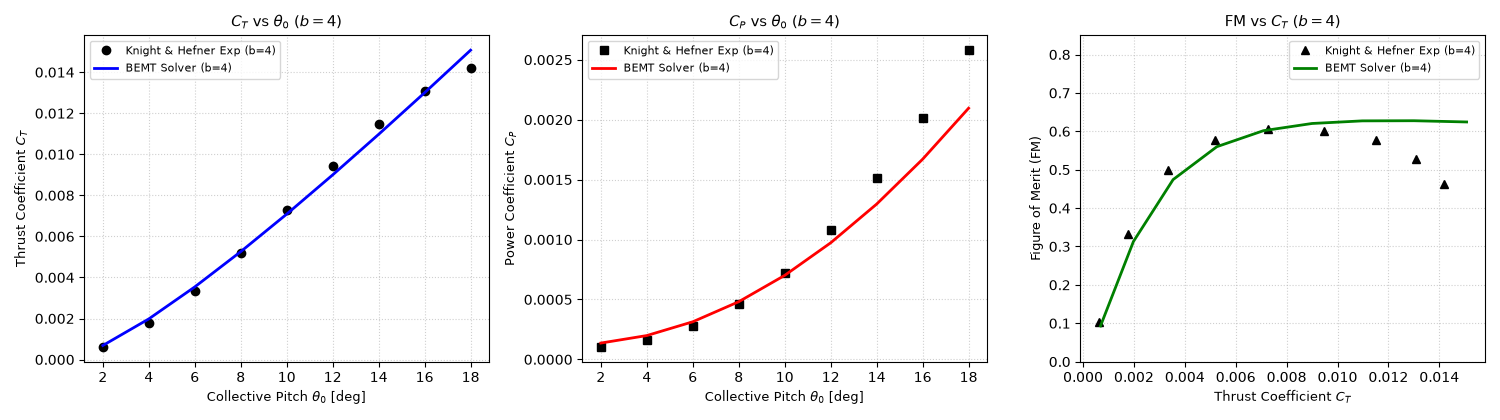

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Knight & Hefner (1937) Baseline (b = 4) ---
R_kh = 0.762          # Rotor Radius [m] 1, 2]
R_rc_kh = 0.125       # Root Cut-out [m] 1, 2]
B_kh = 4              # Number of Blades 1, 2]
c_kh = 0.0508         # Chord Length [m] 1, 2]
rho_sea_level = 1.225 # Air density [kg/m^3]

airfoil_kh = AirfoilModel(
    airfoil_name="Knight & Hefner Analytical",
    cl_slope_fallback=5.75,
    cd0_fallback=0.0113,
    alpha_stall_deg_fallback=14.0
)

cond_kh = FlightCondition(v_axial=0.0, rpm=1200.0, rho=rho_sea_level)

# --- 2. Digitized & Reconciled NACA TN 626 Experimental Data (b = 4) ---
exp_theta_deg = np.array([2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 16.0, 18.0])

# Converted from NACA TN 626 (divided by pi^3/4 and pi^4/8) 2]
exp_ct_b4 = np.array([0.00062, 0.00178, 0.00335, 0.00520, 0.00728, 0.00945, 0.01150, 0.01310, 0.01420])
exp_cp_b4 = np.array([0.000105, 0.000160, 0.000275, 0.000460, 0.000725, 0.001080, 0.001510, 0.002010, 0.002580])
exp_fm_b4 = (exp_ct_b4 ** 1.5) / (np.sqrt(2.0) * exp_cp_b4)

# --- 3. Evaluate BEMT Solver ---
bemt_ct, bemt_cp, bemt_fm = [], [], []

for th in exp_theta_deg:
    geom = RotorGeometry(
        radius=R_kh,
        root_cutout=R_rc_kh,
        num_blades=B_kh,
        chord_func=lambda r: c_kh,
        twist_func=lambda r: np.radians(th)
    )
    res = run_bemt(geom, cond_kh, airfoil_kh, num_elements=50)
    bemt_ct.append(res.ct)
    bemt_cp.append(res.cp)
    bemt_fm.append(res.figure_of_merit)

bemt_ct = np.array(bemt_ct)
bemt_cp = np.array(bemt_cp)
bemt_fm = np.array(bemt_fm)

# --- 4. Error Metrics ---
rmse_ct = np.sqrt(np.mean((bemt_ct - exp_ct_b4)**2))
mae_ct = np.mean(np.abs(bemt_ct - exp_ct_b4))

rmse_cp = np.sqrt(np.mean((bemt_cp - exp_cp_b4)**2))
mae_cp = np.mean(np.abs(bemt_cp - exp_cp_b4))

print("=" * 60)
print(f"BEMT Validation Summary vs Knight & Hefner (1937) [b = {B_kh}]")
print("=" * 60)
print(f"Thrust Coefficient (C_T) -> RMSE: {rmse_ct:.6f} | MAE: {mae_ct:.6f}")
print(f"Power Coefficient  (C_P) -> RMSE: {rmse_cp:.6f} | MAE: {mae_cp:.6f}")
print("=" * 60)

# --- 5. Plots ---
fig, axs = plt.subplots(1, 3, figsize=(15, 4.2), dpi=100)

axs[0].plot(exp_theta_deg, exp_ct_b4, 'ko', markersize=6, label='Knight & Hefner Exp (b=4)')
axs[0].plot(exp_theta_deg, bemt_ct, 'b-', lw=2, label='BEMT Solver (b=4)')
axs[0].set_xlabel(r'Collective Pitch $\theta_0$ [deg]', fontsize=9.5)
axs[0].set_ylabel(r'Thrust Coefficient $C_T$', fontsize=9.5)
axs[0].set_title(r'$C_T$ vs $\theta_0$ ($b=4$)', fontsize=10.5)
axs[0].grid(True, linestyle=':', alpha=0.6)
axs[0].legend(fontsize=8)

axs[1].plot(exp_theta_deg, exp_cp_b4, 'ks', markersize=6, label='Knight & Hefner Exp (b=4)')
axs[1].plot(exp_theta_deg, bemt_cp, 'r-', lw=2, label='BEMT Solver (b=4)')
axs[1].set_xlabel(r'Collective Pitch $\theta_0$ [deg]', fontsize=9.5)
axs[1].set_ylabel(r'Power Coefficient $C_P$', fontsize=9.5)
axs[1].set_title(r'$C_P$ vs $\theta_0$ ($b=4$)', fontsize=10.5)
axs[1].grid(True, linestyle=':', alpha=0.6)
axs[1].legend(fontsize=8)

axs[2].plot(exp_ct_b4, exp_fm_b4, 'k^', markersize=6, label='Knight & Hefner Exp (b=4)')
axs[2].plot(bemt_ct, bemt_fm, 'g-', lw=2, label='BEMT Solver (b=4)')
axs[2].set_xlabel(r'Thrust Coefficient $C_T$', fontsize=9.5)
axs[2].set_ylabel('Figure of Merit (FM)', fontsize=9.5)
axs[2].set_title(r'$\mathrm{FM}$ vs $C_T$ ($b=4$)', fontsize=10.5)
axs[2].set_ylim(0, 0.85)
axs[2].grid(True, linestyle=':', alpha=0.6)
axs[2].legend(fontsize=8)

plt.tight_layout()
plt.show()